# INSTRUCTOR SOLUTION: Exploration Strategies
## AIAT 123 - Reinforcement Learning

**⚠️ INSTRUCTOR USE ONLY**

Complete solution for multi-armed bandit and exploration strategies.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


## Student Support Pack

Use this section to study the solution actively, not passively.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install numpy matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
print('✅ Setup complete!')


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Solution: Multi-Armed Bandit

Simulate ads with different click-through rates

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class MultiArmedBandit:
    def __init__(self, n_arms, true_rewards):
        self.n_arms = n_arms
        self.true_rewards = np.asarray(true_rewards, dtype=float)

    def pull(self, arm: int) -> float:
        p = self.true_rewards[arm]
        return float(np.random.binomial(1, p))

## Solution: Epsilon-Greedy

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def epsilon_greedy(bandit, epsilon=0.1, n_steps=1000):
    q = np.zeros(bandit.n_arms)
    n = np.zeros(bandit.n_arms)
    rewards = []
    for _ in range(n_steps):
        if np.random.random() < epsilon:
            a = np.random.randint(0, bandit.n_arms)
        else:
            a = int(np.argmax(q))
        r = bandit.pull(a)
        n[a] += 1
        q[a] += (r - q[a]) / n[a]
        rewards.append(r)
    return q, np.array(rewards)


## Solution: UCB Algorithm

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def ucb(bandit, c=2, n_steps=1000):
    n = np.zeros(bandit.n_arms)
    q = np.zeros(bandit.n_arms)
    rewards = []
    for t in range(1, n_steps + 1):
        unc = np.where(n == 0, np.inf, c * np.sqrt(np.log(t) / n))
        a = int(np.argmax(q + unc))
        r = bandit.pull(a)
        n[a] += 1
        q[a] += (r - q[a]) / n[a]
        rewards.append(r)
    return q, np.array(rewards)


## Solution: Comparison

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [5]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def cumulative_regret(bandit, rewards_history):
    """Regret vs always picking the best arm (oracle)."""
    best = float(np.max(bandit.true_rewards))
    inst = best - np.asarray(rewards_history, dtype=float)
    return np.cumsum(inst)


bandit_demo = MultiArmedBandit(5, [0.1, 0.3, 0.5, 0.2, 0.4])
_, r_eg = epsilon_greedy(bandit_demo, epsilon=0.1, n_steps=500)
bandit_demo2 = MultiArmedBandit(5, [0.1, 0.3, 0.5, 0.2, 0.4])
_, r_ucb = ucb(bandit_demo2, c=2.0, n_steps=500)
print('epsilon-greedy mean reward', r_eg.mean())
print('ucb mean reward', r_ucb.mean())
print('✅ Demo complete')


epsilon-greedy mean reward 0.464
ucb mean reward 0.396
✅ Demo complete


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_67420/2195804281.py:9: RuntimeWarning: invalid value encountered in divide
  unc = np.where(n == 0, np.inf, c * np.sqrt(np.log(t) / n))
/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_67420/2195804281.py:9: RuntimeWarning: divide by zero encountered in divide
  unc = np.where(n == 0, np.inf, c * np.sqrt(np.log(t) / n))


## Teaching Notes

**Key Insights:**
1. UCB typically outperforms epsilon-greedy
2. UCB balances exploration/exploitation automatically
3. Epsilon-greedy needs tuning of epsilon parameter
4. Real-world: A/B testing, ad optimization, recommendation

**Grading: 100 points**
- Bandit implementation: 20 pts
- Epsilon-greedy: 25 pts
- UCB: 30 pts
- Comparison: 25 pts

**Common Mistakes:**
- Not initializing UCB properly
- Wrong UCB formula
- Not tracking optimal actions
- Poor visualization

**Real-World Applications:**
- Google Ads: Ad selection
- Netflix: Content recommendation
- Amazon: Product placement
- Clinical trials: Treatment selection

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


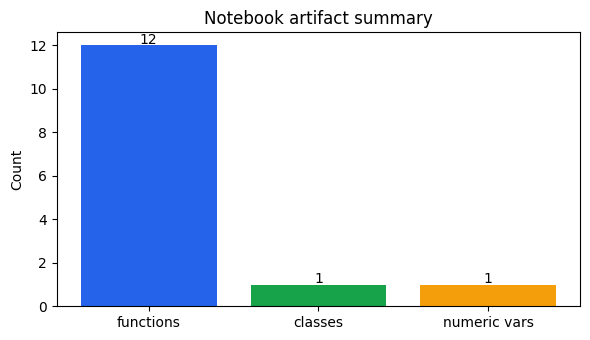

In [6]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
